# Convolutional Neural Network for Sign Language MNIST
## About this dataset

The original MNIST image dataset of handwritten digits is a popular benchmark for image-based machine learning methods but researchers have renewed efforts to update it and develop drop-in replacements that are more challenging for computer vision and original for real-world applications. As noted in one recent replacement called the Fashion-MNIST dataset, the Zalando researchers quoted the startling claim that "Most pairs of MNIST digits (784 total pixels per sample) can be distinguished pretty well by just one pixel". To stimulate the community to develop more drop-in replacements, the Sign Language MNIST is presented here and follows the same CSV format with labels and pixel values in single rows. The American Sign Language letter database of hand gestures represent a multi-class problem with 24 classes of letters (excluding J and Z which require motion).




## Importing dependencies

In [1]:
# import pandas as pd
# import numpy as np
# import cv2
# import tensorflow as tf
# import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

## Specifying the training data and testing data paths

In [2]:
TRAIN_PATH = 'data/sign_mnist_train.csv'
VALID_PATH = 'data/sign_mnist_test.csv'
NO_CLASSES = 26

## Reading the data

In [3]:
trainData = pd.read_csv(TRAIN_PATH)
validData = pd.read_csv(VALID_PATH)

## Transforming the data so that it can be fed into the CNN

In [4]:
x_train = np.array(trainData.drop(columns=['label']))
y_train = np.array(trainData['label'])
x_valid = np.array(validData.drop(columns=['label']))
y_valid = np.array(validData['label'])

## Scaling the data for computational efficiency

In [5]:
x_train = x_train.reshape(len(x_train),28,28,1)
x_train = x_train/255.0
x_valid = x_valid.reshape(len(x_valid),28,28,1)
x_valid = x_valid/255.0

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape

((27455, 28, 28, 1), (27455,), (7172, 28, 28, 1), (7172,))

## Defining Model Architecture

In [7]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(30, (5, 5), input_shape=(28, 28, 1), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Conv2D(15, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(50, activation='relu'))
model.add(tf.keras.layers.Dense(26, activation='softmax'))

## Compiling the model and training it

In [8]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train,y_train, epochs=7, validation_data=(x_valid,y_valid))
model.save('sign_language_mnist_cnn.h5')

Epoch 1/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.5982 - loss: 1.2690 - val_accuracy: 0.8465 - val_loss: 0.4955
Epoch 2/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9180 - loss: 0.2428 - val_accuracy: 0.8834 - val_loss: 0.3870
Epoch 3/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9620 - loss: 0.1169 - val_accuracy: 0.8922 - val_loss: 0.3785
Epoch 4/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.9777 - loss: 0.0698 - val_accuracy: 0.9116 - val_loss: 0.3737
Epoch 5/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9836 - loss: 0.0516 - val_accuracy: 0.9112 - val_loss: 0.3402
Epoch 6/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9855 - loss: 0.0439 - val_accuracy: 0.9247 - val_loss: 0.2766
Epoch 7/7
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9882 - loss: 0.0347 - val_accuracy: 0.9257 - val_loss: 0.3380


### The training accuracy of this model is : ```0.9954```
### The validation accuracy of this model is : ```~92```




## Testing on some data


In [9]:
testImage = x_valid[0] #We will take an image from the training dataset
prediction = model.predict(testImage.reshape(-1,28,28,1)) #Model takes input as 4 dimensions, so we reshape it.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


## Display the result

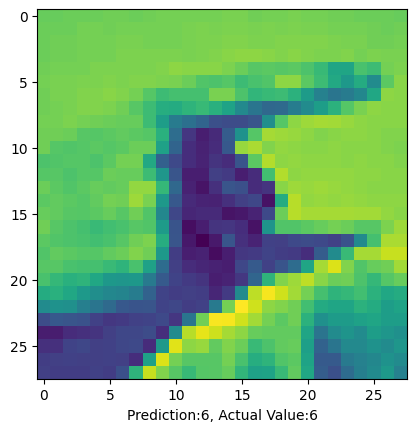

In [10]:
plt.imshow(testImage.reshape(28, 28)) #plt.imshow() requires a 2D array, so we reshape the input
plt.xlabel(f"Prediction:{np.argmax(prediction)}, Actual Value:{y_valid[0]}")
plt.show()